### 비지도 학습
- Target이 없는 데이터 분류하기
- 군집화와 차원축소가 있음

#### 군집 알고리즘
- 과일 데이터를 보고 사과 파인에플 바나나로 3분류하기

In [1]:
import numpy as np

In [6]:
fruits = np.load('data/fruits.npy')
fruits.shape
# 300개의 이미지가 100*100 pxfh rntjd
# 100개는 사과 나머지는 100개씩은 파인에플, 바나나로 구성

(300, 100, 100)

In [8]:
fruits[0,0,:]
# 1장의 흑백 이미지 중 1번행만 출력
# 최대숫자는 255이며 255는 흰색, 0은 흑색을 의미

array([  1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   4,   3,   2,   1,   0,   0,   0,
         0,   6,   1,   0,   4,   3,   0,   1,   8,  14,   0,   0,   4,
         8,  13,  13, 156, 191, 116,  30,   3,   0,   0,   3,   6,   2,
         1,   0,   0,   0,   0,   1,   4,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1], dtype=int32)

In [18]:
import matplotlib.pyplot as plt

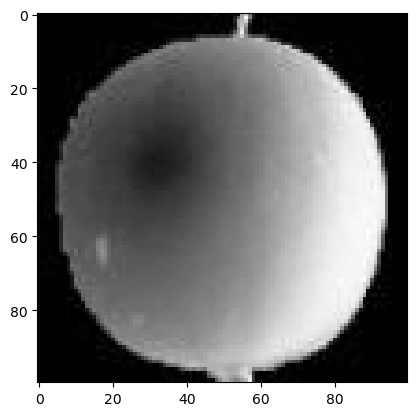

In [20]:
plt.imshow(fruits[0], cmap='gray')
plt.show()

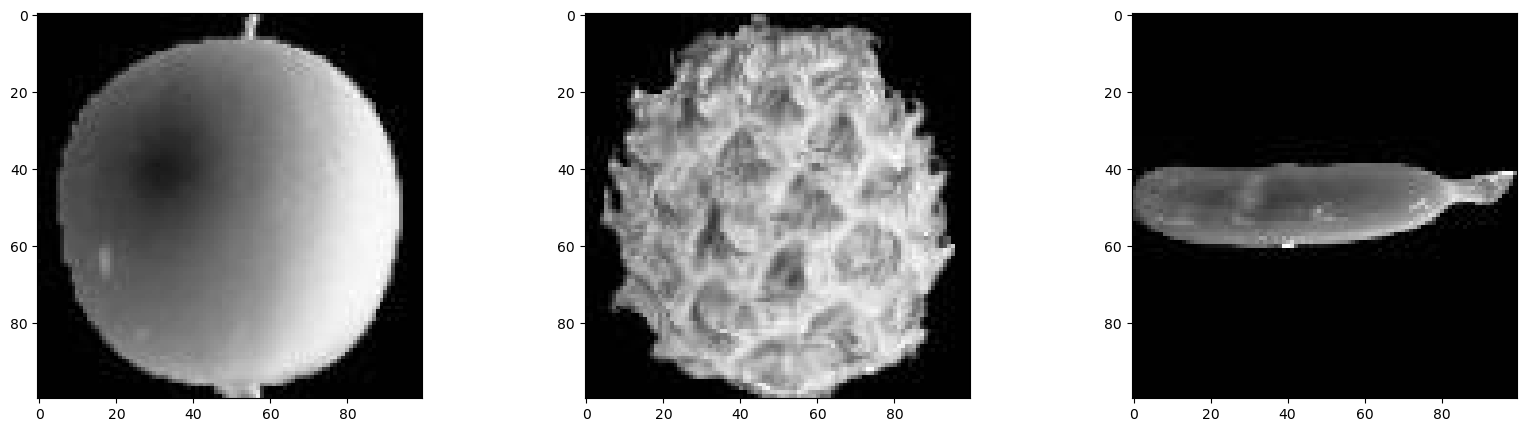

In [26]:
# 사과 바나나 파인에플 이미지 나란히 보기
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].imshow(fruits[0], cmap='gray')
axs[1].imshow(fruits[100], cmap='gray')
axs[2].imshow(fruits[200], cmap='gray')
plt.show()

#### 샘플차원 변경하기
- 현재 3차원의 배열을 분석하기 위해 2차원 배열로 변경
- 배열 중 page단의 변수는 apple, pineapple, banana로 분류하게 변경

In [37]:
apple = fruits[0:100].reshape(-1, 100*100)
pineapple = fruits[100:200].reshape(-1, 100*100)
banana = fruits[200:300].reshape(-1, 100*100)

#### 픽셀값 분석하기

In [38]:
# apple의 행별 평균 구하기
apple.mean(axis=1)

array([ 88.4588,  98.0594,  87.4831,  98.4898,  92.9991,  82.7579,
        94.536 ,  95.7095,  90.7508,  81.7788,  87.1803,  95.2125,
        93.9517,  87.1466,  97.6411,  87.3593,  89.0571, 101.0366,
        92.8971, 101.0462, 105.0824,  88.7961,  99.6585,  97.359 ,
        94.2293,  92.2932,  95.2592,  93.4393, 103.0312,  94.7767,
        90.6388,  89.1673,  97.8923,  97.4053, 100.8732,  90.6799,
       100.3753,  85.9834,  96.5866,  97.2989,  90.8155, 102.4502,
        87.3238,  89.9929,  86.8717,  86.4904,  95.3862,  89.289 ,
        96.9175,  91.782 ,  96.2412,  99.7925,  95.1062,  87.5648,
        89.3416,  89.6668,  93.9096,  97.5639,  87.2779,  97.9526,
       103.3378,  94.5728,  83.8009,  83.6077, 102.9481,  87.1496,
        91.3842, 100.5921,  93.9603,  90.9806,  97.5707,  97.574 ,
        82.5605,  87.2897,  97.0628,  90.4258,  90.6506,  97.741 ,
        98.1869,  93.7264,  87.536 ,  84.8565,  89.2303,  86.8919,
        88.8434,  86.7783,  96.8703,  97.3682,  82.0917,  87.3

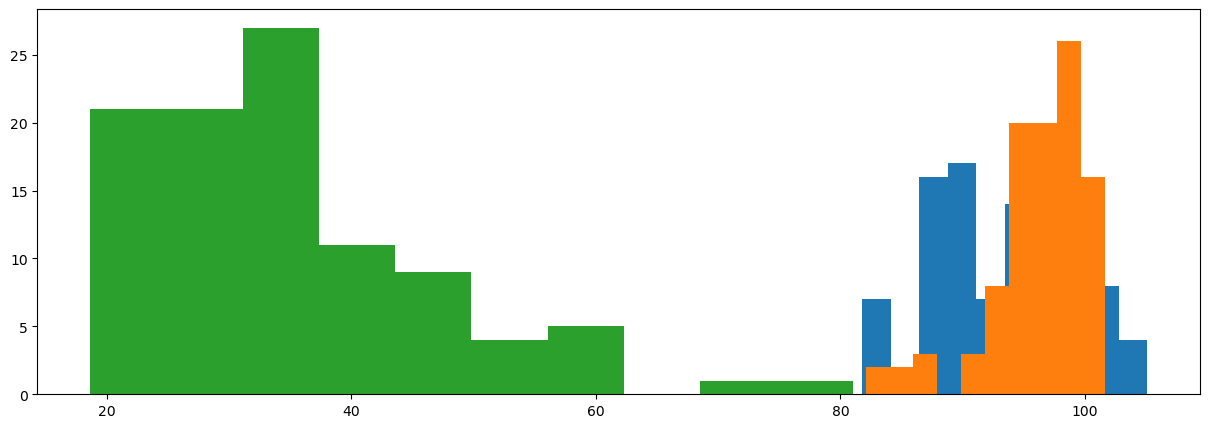

In [39]:
# 과일별 빈도수를 히스토그램으로 표현하기
plt.figure(figsize=(15, 5))
plt.hist(np.mean(apple, axis=1))
plt.hist(np.mean(pineapple, axis=1))
plt.hist(np.mean(banana, axis=1))
plt.show()

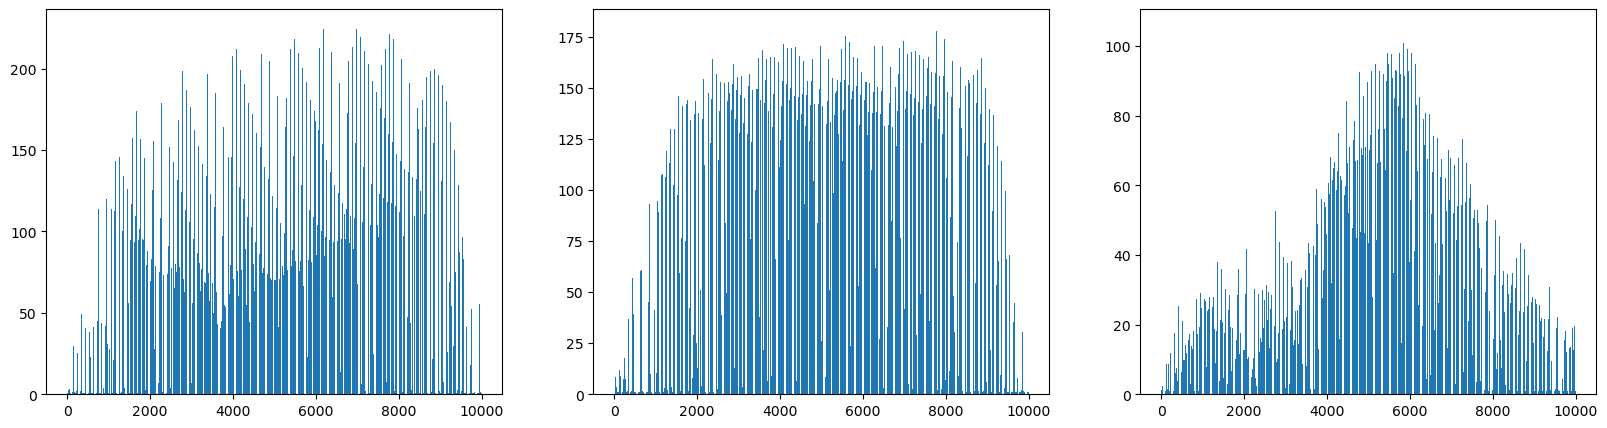

In [42]:
# Feature별(픽셀별) 평균의 막대 그래프 만들기
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].bar(range(10000), np.mean(apple, axis=0))
axs[1].bar(range(10000), np.mean(pineapple, axis=0))
axs[2].bar(range(10000), np.mean(banana, axis=0))
plt.show()

In [47]:
# 평균 이미지로 그림 표현하기: 이미지로 그리기 위해 다시 2차원 배열로 변경
apple_mean = np.mean(apple, axis=0).reshape(100, 100)
pineapple_mean = np.mean(pineapple, axis=0).reshape(100, 100)
banana_mean = np.mean(banana, axis=0).reshape(100, 100)
apple_mean.shape

(100, 100)

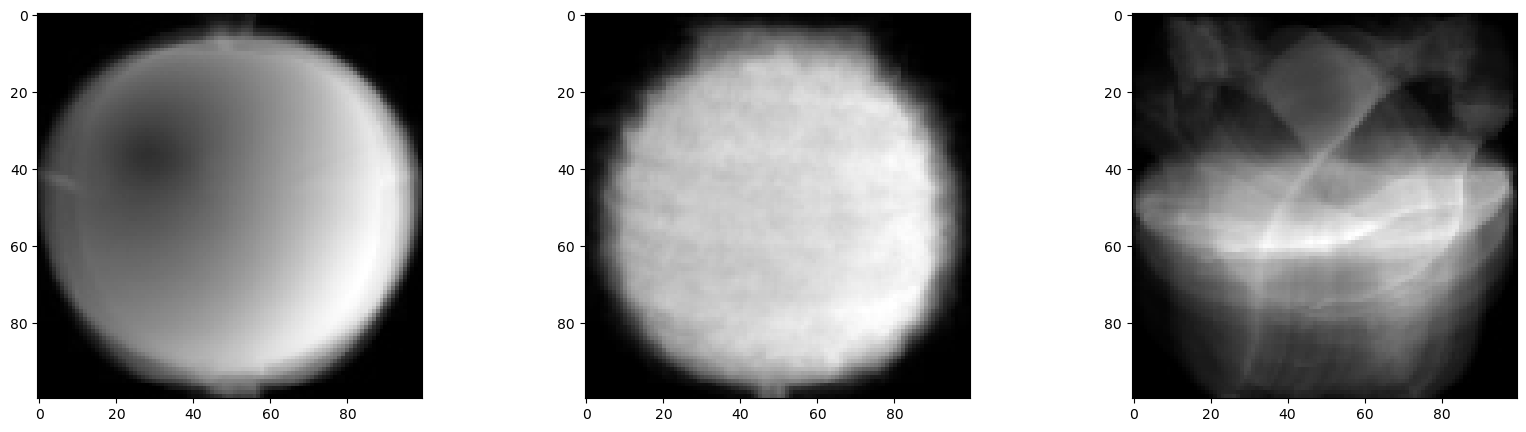

In [50]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].imshow(apple_mean, cmap='gray')
axs[1].imshow(pineapple_mean, cmap='gray')
axs[2].imshow(banana_mean, cmap='gray')
plt.show()

#### 평균과 가까운 사진 구하기
- 위에서 구한 평균 이미지와 각 샘플들의 픽셀값과 비교하여 가까운 거리의 이미지는 해당 과일일 것이다.

In [53]:
abs_diff = np.abs(fruits- apple_mean)
abs_mean = np.mean(abs_diff, axis=(1,2))
abs_mean.shape

(300,)

In [57]:
apple_index = np.argsort(abs_mean)[:100]

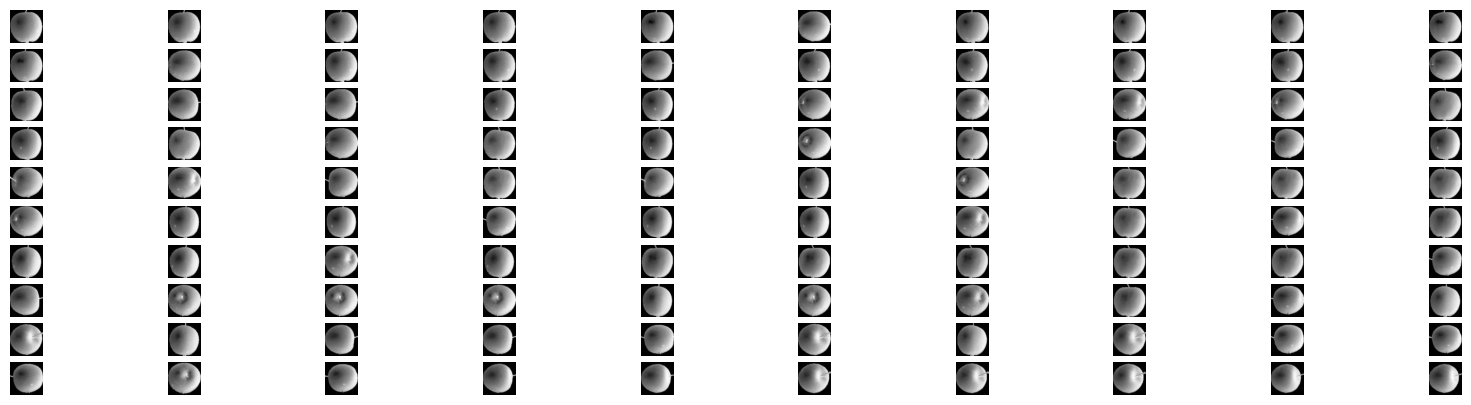

In [60]:
fig, axs = plt.subplots(10, 10, figsize=(20, 5))
for i in range(10):
    for j in range(10):
        axs[i, j].imshow(fruits[apple_index[i*10+j]], cmap='gray')
        axs[i, j].axis('off')
plt.show()

In [62]:
abs_diff = np.abs(fruits- banana_mean)
abs_mean = np.mean(abs_diff, axis=(1,2))
abs_mean.shape

(300,)

In [63]:
banana_index = np.argsort(abs_mean)[:100]

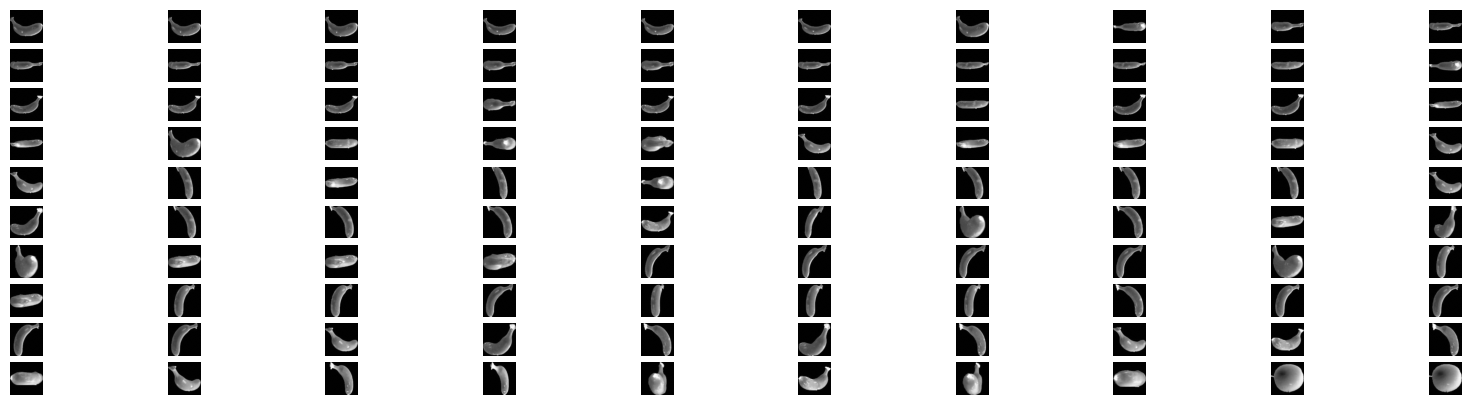

In [65]:
fig, axs = plt.subplots(10, 10, figsize=(20, 5))
for i in range(10):
    for j in range(10):
        axs[i, j].imshow(fruits[banana_index[i*10+j]], cmap='gray')
        axs[i, j].axis('off')
plt.show()

In [66]:
abs_diff = np.abs(fruits- pineapple_mean)
abs_mean = np.mean(abs_diff, axis=(1,2))
abs_mean.shape
pineapple_index = np.argsort(abs_mean)[:100]

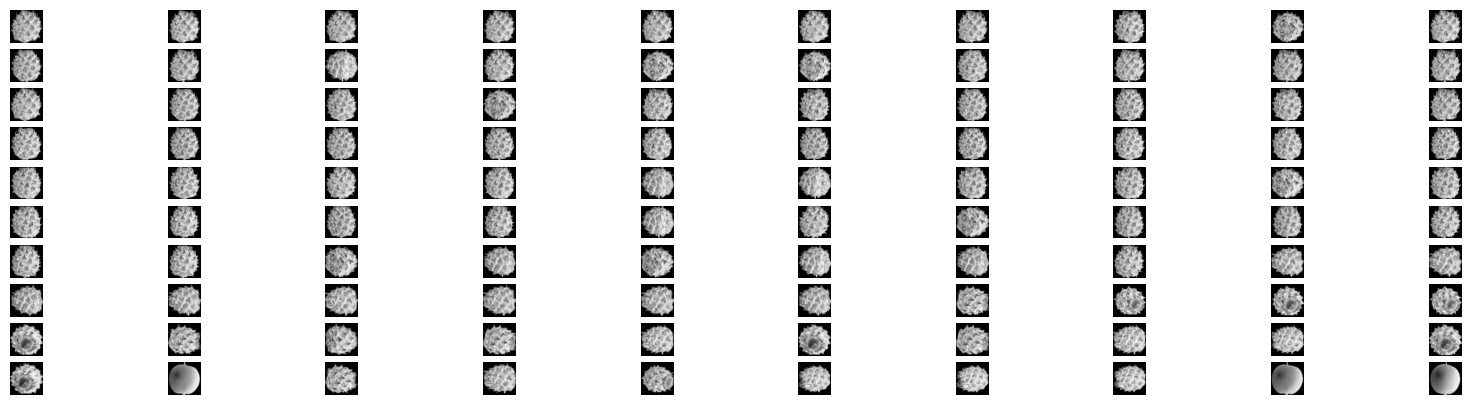

In [67]:
fig, axs = plt.subplots(10, 10, figsize=(20, 5))
for i in range(10):
    for j in range(10):
        axs[i, j].imshow(fruits[pineapple_index[i*10+j]], cmap='gray')
        axs[i, j].axis('off')
plt.show()